In [1]:
from ngsolve import *
from ngsolve.webgui import Draw
import matplotlib.pyplot as plt

In [3]:
mesh = Mesh (unit_square.GenerateMesh(maxh=0.2))
Draw(mesh)

WebGuiWidget(layout=Layout(height='50vh', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.26…

BaseWebGuiScene

In [23]:
print(x)
print(type(x))
Draw(x, mesh)

coef coordinate x, real

<class 'ngsolve.fem.CoefficientFunction'>


WebGuiWidget(layout=Layout(height='50vh', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.26…

BaseWebGuiScene

In [25]:
Draw(y, mesh)

WebGuiWidget(layout=Layout(height='50vh', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.26…

BaseWebGuiScene

In [26]:
myfunc = x * (1 - x)
print(myfunc)
print(type(myfunc))
Draw(myfunc, mesh)

coef binary operation '*', real
  coef coordinate x, real
  coef binary operation '-', real
    coef 1, real
    coef coordinate x, real

<class 'ngsolve.fem.CoefficientFunction'>


WebGuiWidget(layout=Layout(height='50vh', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.26…

BaseWebGuiScene

In [32]:
mip = mesh(0.2, 0.3)
myfunc(mip)

0.16000000000000003

In [34]:
pts = [(0.1*i, 0.2) for i in range(11)]
vals = [myfunc(mesh(*p)) for p in pts] 
for p,v in zip(pts, vals):
    print("point=(%3.2f,%3.2f), value=%6.5f"
         %(p[0], p[1], v))

point=(0.00,0.20), value=0.00000
point=(0.10,0.20), value=0.09000
point=(0.20,0.20), value=0.16000
point=(0.30,0.20), value=0.21000
point=(0.40,0.20), value=0.24000
point=(0.50,0.20), value=0.25000
point=(0.60,0.20), value=0.24000
point=(0.70,0.20), value=0.21000
point=(0.80,0.20), value=0.16000
point=(0.90,0.20), value=0.09000
point=(1.00,0.20), value=0.00000


In [36]:
import numpy as np
X = np.linspace(0, 1, num=11)
print(X)
Y = np.ones_like(X) * 0.2
print(Y)
myfunc(mesh(X, Y))

[0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]
[0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2]


array([[0.  ],
       [0.09],
       [0.16],
       [0.21],
       [0.24],
       [0.25],
       [0.24],
       [0.21],
       [0.16],
       [0.09],
       [0.  ]])

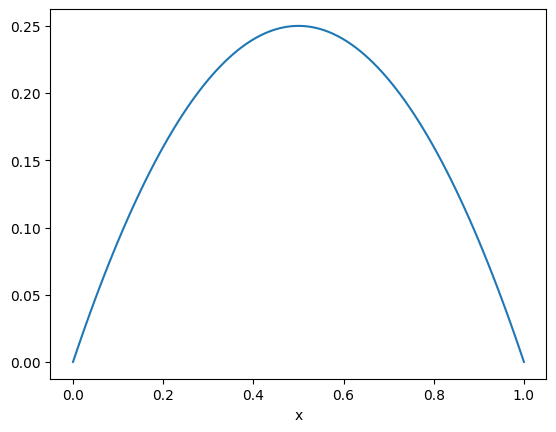

In [37]:
X = np.linspace(0, 1, num=100)
Y = np.ones_like(X) * 0.2
plt.plot(X, myfunc(mesh(X, Y)))
plt.xlabel('x')
plt.show()

In [40]:
fes = H1(mesh, order=1)
u = GridFunction(fes)
u.Set(myfunc)
Draw(u); 

WebGuiWidget(layout=Layout(height='50vh', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.26…

In [47]:
vecfun = CoefficientFunction((-y, sin(x)))
print(vecfun)
Draw(vecfun, mesh, vectors=True);

coef unary operation ' ', real, dim=2
  coef VectorialCoefficientFunction, real, dim=2
    coef scale -1, real
      coef coordinate y, real
    coef unary operation 'sin', real
      coef coordinate x, real



WebGuiWidget(layout=Layout(height='50vh', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.26…

In [48]:
u.Set(myfunc)
gradu = grad(u)
Draw(gradu, mesh, vectors={"grid_size":30});

WebGuiWidget(layout=Layout(height='50vh', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.26…

In [51]:
myfunc_compiled = myfunc.Compile()
print(myfunc)
print(myfunc_compiled)

coef binary operation '*', real
  coef coordinate x, real
  coef binary operation '-', real
    coef 1, real
    coef coordinate x, real

Compiled CF:
Step 0: coordinate x
Step 1: 1
Step 2: binary operation '-'
     input: 1 0 
Step 3: binary operation '*'
     input: 0 2 

